# Active Lives 2022-23 — London EDA & Multi-Pillar Analysis (Wave 8)

Companion to the 2015-16 wave notebook. The data is a **pre-filtered London CSV**
(16,515 respondents, 601 columns) — survey missing codes already blanked. A CSV carries no
value labels, so we supply a manual codebook to decode numeric codes to readable labels.

Covers all four project pillars with **per-borough breakdowns** throughout:
**(1) Participation**, **(2) Demographics**, **(3) Indoor vs Outdoor**, **(4) Volunteering** —
plus deeper EDA (missingness, distributions, associations) and a weighted regression.

> **Activity outcome:** `MEMS7GR_SPORTCOUNT_A01` (Sport England "count" definition;
> 0=Inactive, 1=Fairly Active, 2=Active) — same measure as 2015-16, so comparable.

> **Borough mapping note:** the CSV's `LA_2021` numbering diverges from the `.sav` value-label
> dictionary for 11 of the 33 London codes. It was reconciled by cross-referencing the older
> boundary-vintage columns (`LA_2019`/`LA_2015`) against the official GSS dictionary. The
> resulting verified map is hard-coded below (`LONDON_LA2021`) and saved to JSON.

## 1. Load the pre-filtered London CSV

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV = "C:/Users/Lenovo/London-Sport-Forecasting-Patterns/data/processed/active_lives_london_y8_2022-23.csv"   # <-- adjust path if needed
df = pd.read_csv(CSV)
print("shape:", df.shape)
print("survey year:", df["survey_year"].unique())

shape: (16515, 601)
survey year: ['2022-23']


## 2. Codebook — decode numeric codes to labels

The CSV has no embedded value labels, so we map codes manually. **All codings below have been
verified against the `.sav` value-label dictionary** for this wave. Verification caught two real
mislabels that would otherwise have silently corrupted results:

> **Corrections applied (verified against `.sav`):**
> - `Disab3` is `1=Limiting, 2=Non-limiting, 3=No disability` — the *reverse* of a common
>   assumption. The inverted version mislabelled the disability breakdown and regression reference.
> - `NSSEC5` is social-group bands (Higher/Middle/Lower/Students), not occupation classes.
> - `Educ6` is qualification *levels* (Level 4+, Level 3, …), not named qualifications.
>
> For a new wave, re-verify: banded codings (`Age9`, `NSSEC5`, `BMIG`, `health`, `Educ6`) can
> change between years. Ideally generate the codebook from that wave's `.sav` rather than reuse this one.

In [2]:
CODEBOOK = {
    "MEMS7GR_SPORTCOUNT_A01": {0: "Inactive", 1: "Fairly Active", 2: "Active"},
    "MEMS7GR_ALL":            {0: "Inactive", 1: "Fairly Active", 2: "Active"},
    "MEMS7GR_IN_SPORTCOUNT_A01":  {0: "Inactive", 1: "Fairly Active", 2: "Active"},
    "MEMS7GR_OUT_SPORTCOUNT_A01": {0: "Inactive", 1: "Fairly Active", 2: "Active"},
    "Gend3": {1: "Male", 2: "Female", 3: "Other"},
    "Eth7":  {1: "White British", 2: "White Other", 3: "Asian (excl. Chinese)",
              4: "Black", 5: "Chinese", 6: "Mixed", 7: "Other ethnic group"},
    "Eth2":  {1: "White British", 2: "Other than White British"},
    "Disab3": {1: "Limiting disability", 2: "Non-limiting disability", 3: "No disability"},
    "Disab2_POP": {1: "Disability", 2: "No disability"},
    # Verified: Age9
    "Age9": {1: "14-15", 2: "16-24", 3: "25-34", 4: "35-44", 5: "45-54",
             6: "55-64", 7: "65-74", 8: "75-84", 9: "85+"},
    "Age5_2": {1: "16-24", 2: "25-44", 3: "45-64", 4: "65-74", 5: "75+"},
    # Verified against .sav value labels:
    "NSSEC5": {1: "Higher social groups (NS-SEC 1-2)", 2: "Middle social groups (NS-SEC 3-5)",
               3: "Lower social groups (NS-SEC 6-8)", 4: "Students and other/unclassified"},
    "Educ6": {1: "Level 4 or above", 2: "Level 3 and equivalents", 3: "Level 2 and equivalents",
              4: "Level 1 and below", 5: "Another type of qualification", 6: "No qualifications"},
    # Verified: health
    "health": {1: "Very good", 2: "Good", 3: "Fair", 4: "Bad", 5: "Very bad"},
    # Verified: BMIG (-1 = no data, caught by missing-code strip)
    "BMIG": {1: "Underweight", 2: "Healthy weight", 3: "Overweight",
             4: "Obese", 5: "Morbidly obese"},
    "VolAny": {0: "Did not volunteer", 1: "Volunteered"},
    "VolCnt_GR2": {0: "None", 1: "One role", 2: "Two or more roles"},
    "VolFrqB_Pop": {0: "Not in last month", 1: "Less than weekly", 2: "Weekly",
                    3: "Several times a week", 4: "Daily"},
}
VOL_ROLES = {   # verified against .sav question text
    "volint1_vol": "Raising funds", "volint2_vol": "Providing transport",
    "volint3_vol": "Coaching/instructing", "volint4_vol": "Refereeing/officiating",
    "volint5_vol": "Administrative/committee role", "volint6_vol": "Stewarding/marshalling",
    "volint7_vol": "Other help",
}
print("Codebook ready.")

Codebook ready.


## 3. Borough mapping (verified) — `LA_2021` → GSS code + name

The verified London map, reconciled against `LA_2019`/`LA_2015` and the official GSS
dictionary. 33 London authorities; City of London (`E09000001`) is excluded per the project
scope, leaving the 32 boroughs.

In [3]:
LONDON_LA2021 = {
    9:("E09000002","Barking and Dagenham"), 8:("E09000003","Barnet"),
    17:("E09000004","Bexley"), 30:("E09000005","Brent"), 35:("E09000006","Bromley"),
    44:("E09000007","Camden"), 59:("E09000001","City of London"),
    69:("E09000008","Croydon"), 80:("E09000009","Ealing"), 94:("E09000010","Enfield"),
    110:("E09000011","Greenwich"), 112:("E09000012","Hackney"),
    115:("E09000013","Hammersmith and Fulham"), 117:("E09000014","Haringey"),
    120:("E09000015","Harrow"), 125:("E09000016","Havering"),
    129:("E09000017","Hillingdon"), 132:("E09000018","Hounslow"),
    139:("E09000019","Islington"), 138:("E09000020","Kensington and Chelsea"),
    143:("E09000021","Kingston upon Thames"), 146:("E09000022","Lambeth"),
    151:("E09000023","Lewisham"), 164:("E09000024","Merton"), 175:("E09000025","Newham"),
    201:("E09000026","Redbridge"), 206:("E09000027","Richmond upon Thames"),
    247:("E09000028","Southwark"), 261:("E09000029","Sutton"),
    278:("E09000030","Tower Hamlets"), 285:("E09000031","Waltham Forest"),
    286:("E09000032","Wandsworth"), 300:("E09000033","Westminster"),
}

# Save the authoritative map so it never needs reconstructing
import json
with open("la2021_london_map.json", "w") as f:
    json.dump({str(k): list(v) for k, v in LONDON_LA2021.items()}, f, indent=2)
print("saved la2021_london_map.json")

saved la2021_london_map.json


## 4. Configure, decode, and build the London analysis frame

In [4]:
CONFIG = {
    "weight":"wt_final", "la_code":"LA_2021",
    "activity_band":"MEMS7GR_SPORTCOUNT_A01",
    "activity_in":"MEMS7GR_IN_SPORTCOUNT_A01", "activity_out":"MEMS7GR_OUT_SPORTCOUNT_A01",
    "age":"Age9", "gender":"Gend3", "ethnicity":"Eth7", "disability":"Disab3",
    "nssec":"NSSEC5", "education":"Educ6", "health":"health", "bmi":"BMIG",
    "volunteer":"VolAny",
}

def decode(df, config, codebook):
    out = df.copy()
    for concept, var in config.items():
        if var in codebook:
            out[concept] = out[var].map(codebook[var])
        elif var in out.columns:
            out[concept] = out[var]
    out["weight"] = pd.to_numeric(out[config["weight"]], errors="coerce")
    return out

# Exclude 14-15 (out of scope for an adult survey); here it removes 0 rows.
df = df[df["Age9"] != 1.0].copy()
data = decode(df, CONFIG, CODEBOOK)

# Apply the verified borough map and restrict to London boroughs (exclude City of London)
data["gss"]     = data["LA_2021"].map({k:v[0] for k,v in LONDON_LA2021.items()})
data["LA_name"] = data["LA_2021"].map({k:v[1] for k,v in LONDON_LA2021.items()})
london = data[data["gss"].notna() & (data["gss"] != "E09000001")].copy()

assert london["LA_name"].nunique() == 32, "Expected 32 boroughs"
print(f"London analysis frame: {len(london):,} rows, {london['LA_name'].nunique()} boroughs")

London analysis frame: 16,515 rows, 32 boroughs


## 4b. Reproducibility guard — `validate_wave`

Other waves have their **columns renamed to match this 2022-23 baseline**, so the structure is
reproducible. But renaming columns does **not** standardise the *values* inside them — borough
code numbering, categorical codings, and missing-code handling can still differ per year, and
those errors are silent (they don't raise). This guard checks the value-level assumptions and
**fails loudly** so a new wave is never analysed on wrong assumptions. Run it first on any new CSV.

In [5]:
def validate_wave(df, wave_label, expected_active=None, tol=0.05):
    """Value-level checks that renaming columns does NOT guarantee. Prints PASS/CHECK per item."""
    issues = []
    need = ["wt_final","LA_2021","MEMS7GR_SPORTCOUNT_A01","Eth7","Disab3","Age9","VolAny"]
    miss = [c for c in need if c not in df.columns]
    if miss: issues.append(f"MISSING COLUMNS: {miss}")

    # Survey missing-codes should already be stripped (no negatives in coded vars)
    coded = [c for c in ["MEMS7GR_SPORTCOUNT_A01","Eth7","Disab3"] if c in df.columns]
    if coded and (df[coded] < 0).any().any():
        issues.append("Negative survey codes present — strip -90..-99 before analysis")

    # Disability prevalence sanity (catches Disab3-style reversals): code 1 = Limiting
    if "Disab3" in df.columns:
        lim = (df["Disab3"] == 1).mean()
        if not (0.05 < lim < 0.35):
            issues.append(f"Limiting-disability rate {lim:.0%} implausible — check Disab3 coding")

    # Borough mapping coverage on LA_2021
    if "LA_2021" in df.columns:
        cov = df["LA_2021"].map({k: v[0] for k, v in LONDON_LA2021.items()}).notna().mean()
        if cov < 0.95:
            issues.append(f"Only {cov:.0%} of rows map to a London borough — LA_2021 numbering differs; rebuild map")

    # National active rate vs published Sport England headline for that year (if supplied)
    if expected_active is not None and "MEMS7GR_SPORTCOUNT_A01" in df.columns and "wt_final" in df.columns:
        d = df.dropna(subset=["MEMS7GR_SPORTCOUNT_A01","wt_final"])
        rate = ((d["MEMS7GR_SPORTCOUNT_A01"] == 2) * d["wt_final"]).sum() / d["wt_final"].sum()
        if abs(rate - expected_active) > tol:
            issues.append(f"Weighted active rate {rate:.1%} differs from expected {expected_active:.0%} by >{tol:.0%}")

    print(f"=== validate_wave: {wave_label} -> {'PASS' if not issues else 'CHECK NEEDED'} ===")
    for i in issues: print("  -", i)
    return issues

# Validate the baseline itself (expected ~62% active per Sport England 2022-23)
validate_wave(df, "2022-23 (baseline)", expected_active=0.62)

=== validate_wave: 2022-23 (baseline) -> PASS ===


[]

## 5. Weighted summary helpers

In [6]:
def weighted_share(df, group_cols, target_col, target_value):
    d = df.dropna(subset=["weight", target_col]).copy()
    d["_num"] = (d[target_col] == target_value).astype(float) * d["weight"]
    if group_cols:
        g = d.groupby(group_cols, dropna=False)
        out = (g["_num"].sum() / g["weight"].sum()).rename("weighted_share").reset_index()
        out["n"] = g.size().values
        return out
    return d["_num"].sum() / d["weight"].sum()

def weighted_distribution(df, group_col, target_col="activity_band"):
    d = df.dropna(subset=["weight", target_col, group_col]).copy()
    tab = d.groupby([group_col, target_col])["weight"].sum().unstack(fill_value=0)
    return tab.div(tab.sum(axis=1), axis=0)

## 6. EDA — missingness map

Two kinds: ordinary item non-response (a few %), and **structural** missingness on questions
only asked of a rotation subgroup (indoor/outdoor ~61%). Structural missingness is by design;
it shrinks the weighted base for those analyses.

activity_in      0.614
activity_out     0.614
volunteer        0.223
bmi              0.189
nssec            0.080
disability       0.070
ethnicity        0.070
education        0.032
health           0.023
age              0.008
gender           0.002
activity_band    0.000
weight           0.000


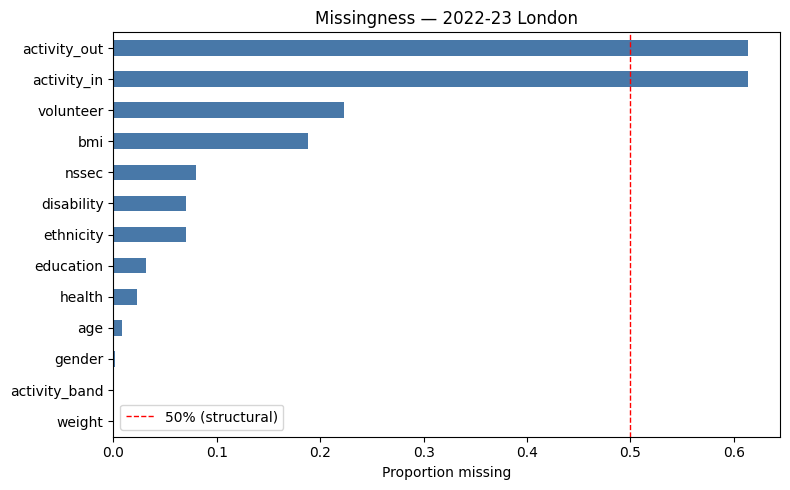

In [7]:
concept_cols = ["activity_band","activity_in","activity_out","age","gender","ethnicity",
                "disability","nssec","education","health","bmi","volunteer","weight"]
miss = london[concept_cols].isna().mean().sort_values(ascending=False)
print(miss.round(3).to_string())

fig, ax = plt.subplots(figsize=(8,5))
miss.sort_values().plot(kind="barh", ax=ax, color="#4878a8")
ax.axvline(0.5, color="red", ls="--", lw=1, label="50% (structural)")
ax.set_xlabel("Proportion missing"); ax.set_title("Missingness — 2022-23 London")
ax.legend(); plt.tight_layout(); plt.show()

In [8]:
def check_routing(df, gate_col, gate_value, dependent_cols, label=""):
    """Among rows where gate_col==gate_value, how complete are the dependents?
    ~0% missing = clean universal routing; high+uniform = rotation subsample."""
    cols = [c for c in dependent_cols if c in df.columns]
    sub = df[df[gate_col] == gate_value]
    miss = sub[cols].isna().mean().round(3)
    all_blank = sub[cols].isna().all(axis=1).sum()
    print(f"{label or gate_col}=={gate_value!r} (n={len(sub)}): "
          f"max dep-missing={miss.max():.3f}, all-blank={all_blank} ({all_blank/max(len(sub),1):.1%})")

# Volunteer roles asked only of volunteers; impairment types only of disabled respondents
role_cols = [c for c in london.columns if c.startswith("volint")]
check_routing(london, "volunteer", "Volunteered", role_cols, "Volunteer -> role detail")
disty = [c for c in london.columns if c.startswith("disty")]
check_routing(london, "disability", "Limiting disability", disty, "Limiting disability -> impairment types")

Volunteer -> role detail=='Volunteered' (n=2267): max dep-missing=0.000, all-blank=0 (0.0%)
Limiting disability -> impairment types=='Limiting disability' (n=2628): max dep-missing=0.021, all-blank=56 (2.1%)


## 6b. Missingness Report

Missingness here is not a single phenomenon. Each variable's blanks arise from one of four
distinct causes, established through routing-integrity checks (above) rather than assumed from the
percentage. Missing values are **reported, not imputed** — imputation would fabricate unasked
answers (structural cases) or distort the demographic gradients under study (item non-response).

### Missingness by variable

| Variable | % Missing | Type | Why it exists |
|---|---|---|---|
| `weight` | 0.0 | — | Complete. Required for every weighted figure. |
| `activity_band` | 0.0 | — | Headline outcome; asked of all respondents, fully complete. |
| `gender` | 0.2 | Item non-response | Basic demographic; negligible refusal. |
| `age` | 0.8 | Item non-response | Basic demographic; very low refusal. |
| `health` | 2.3 | Item non-response | Sensitive self-report; small decline rate. |
| `education` | 3.2 | Item non-response | Optional question. |
| `ethnicity` | 7.0 | Item non-response | Optional/sensitive; modest decline rate. |
| `disability` | 7.0 | Item non-response | Sensitive question; modest decline. Routing into impairment detail verified clean (0% gate-conditional). |
| `nssec` | 8.0 | Derived / item non-response | Derived from occupation; blank where occupation data insufficient. |
| `bmi` | 18.9 | Derived / item non-response | Derived from height + weight; blank if either input missing. |
| `volunteer` (VolAny) | 22.3 | **Structural (rotation)** | Volunteering module only put to a rotation subgroup; those not asked are blank. Among those asked, status is complete. |
| `activity_in` | 61.4 | **Structural (rotation)** | Indoor setting only asked of a rotation subgroup; ~61% never asked. Smaller base — indicative. |
| `activity_out` | 61.4 | **Structural (rotation)** | Outdoor setting, same rotation subgroup as `activity_in`. |
| `volint1-7` (roles) | 0.0* | **Structural (skip)** | *Among volunteers.* Asked only of people who volunteered — by design. Verified 0% missing among volunteers: routing is clean. |

### The four causes
1. **Structural rotation (largest):** question rotation means not every respondent gets every
   module. Indoor/outdoor (61.4%) and the volunteering gate (22.3%) are blank for the subgroup
   never asked. Information, not error — analysed on a representative subsample, reported with its
   reduced base, never imputed.
2. **Structural skip:** follow-ups blank because the respondent didn't reach that branch (roles →
   volunteers only; impairment types → disabled only). Routing checks confirm 0% gate-conditional
   missingness — clean.
3. **Item non-response (2–8%):** asked but declined; concentrated in optional/sensitive questions.
   Handled by per-calculation listwise deletion on the largest valid base.
4. **Derived-variable:** `bmi` (height+weight) and `nssec` (occupation) are blank when an input is
   missing — a downstream consequence of (3), not a separate refusal. BMI is higher as it needs two inputs.

### Handling principles
- **Never imputed.** **Per-calculation exclusion** (not whole-respondent). **Base always reported**
  for subgroup analyses. **Verified, not assumed** — routing checks confirmed structural vs refusal.

> **Cross-wave note:** missingness *structure* can differ between survey years — a question
> universal in one wave may be rotated in another. Any trend in a subgroup-based figure must be
> checked against whether the underlying base changed before being read as behavioural change.

## 7. EDA — weight validity & sample composition

Weight: min=0.1688 max=16.75 non-positive=0 missing=0


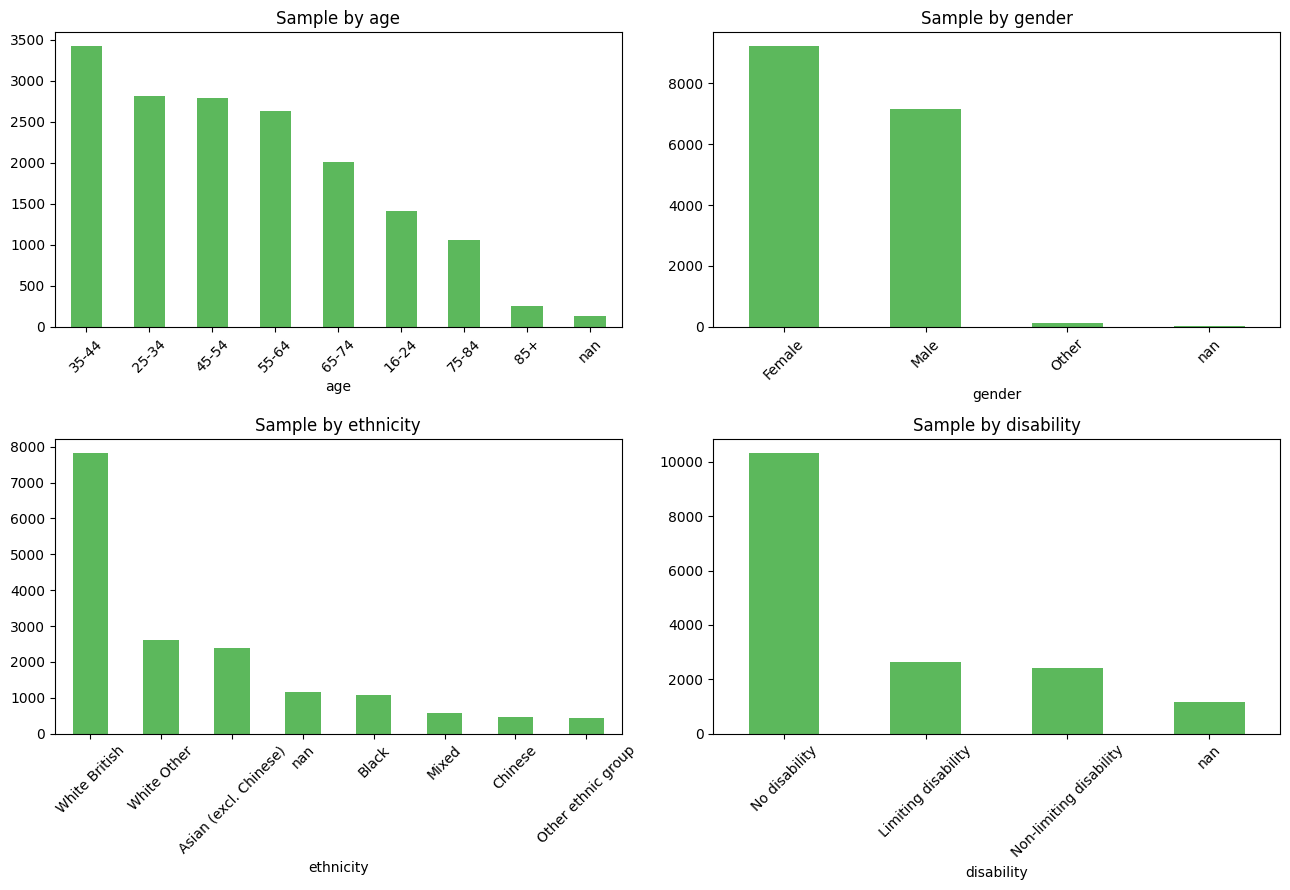

In [9]:
w = london["weight"]
print("Weight: min={:.4f} max={:.2f} non-positive={} missing={}".format(
    w.min(), w.max(), int((w<=0).sum()), int(w.isna().sum())))

fig, axes = plt.subplots(2,2, figsize=(13,9))
for ax, c in zip(axes.ravel(), ["age","gender","ethnicity","disability"]):
    london[c].value_counts(dropna=False).plot(kind="bar", ax=ax, color="#5cb85c")
    ax.set_title(f"Sample by {c}"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 8. Pillar 1 — Participation / activity levels
Overall, by demographic, and **by borough**. Compare overall to 2015-16 London (63.5%).

In [10]:
overall = weighted_share(london, [], "activity_band", "Active")
print(f"Overall London % Active (2022-23): {overall:.3f}   (2015-16 was 0.635)")
for factor in ["age","gender","ethnicity","disability","nssec","education","health","bmi"]:
    print(f"\n=== % Active by {factor} ===")
    print(weighted_share(london, [factor], "activity_band", "Active").dropna(subset=[factor]).to_string(index=False))

Overall London % Active (2022-23): 0.643   (2015-16 was 0.635)

=== % Active by age ===
  age  weighted_share    n
16-24        0.692668 1407
25-34        0.714610 2816
35-44        0.661886 3417
45-54        0.636985 2786
55-64        0.605998 2626
65-74        0.600738 2011
75-84        0.460012 1058
  85+        0.281300  258

=== % Active by gender ===
gender  weighted_share    n
Female        0.616140 9210
  Male        0.672295 7150
 Other        0.591275  121

=== % Active by ethnicity ===
            ethnicity  weighted_share    n
Asian (excl. Chinese)        0.571679 2387
                Black        0.544369 1078
              Chinese        0.602819  451
                Mixed        0.694052  571
   Other ethnic group        0.582497  442
        White British        0.703196 7828
          White Other        0.698500 2599

=== % Active by disability ===
             disability  weighted_share     n
    Limiting disability        0.480208  2628
          No disability       

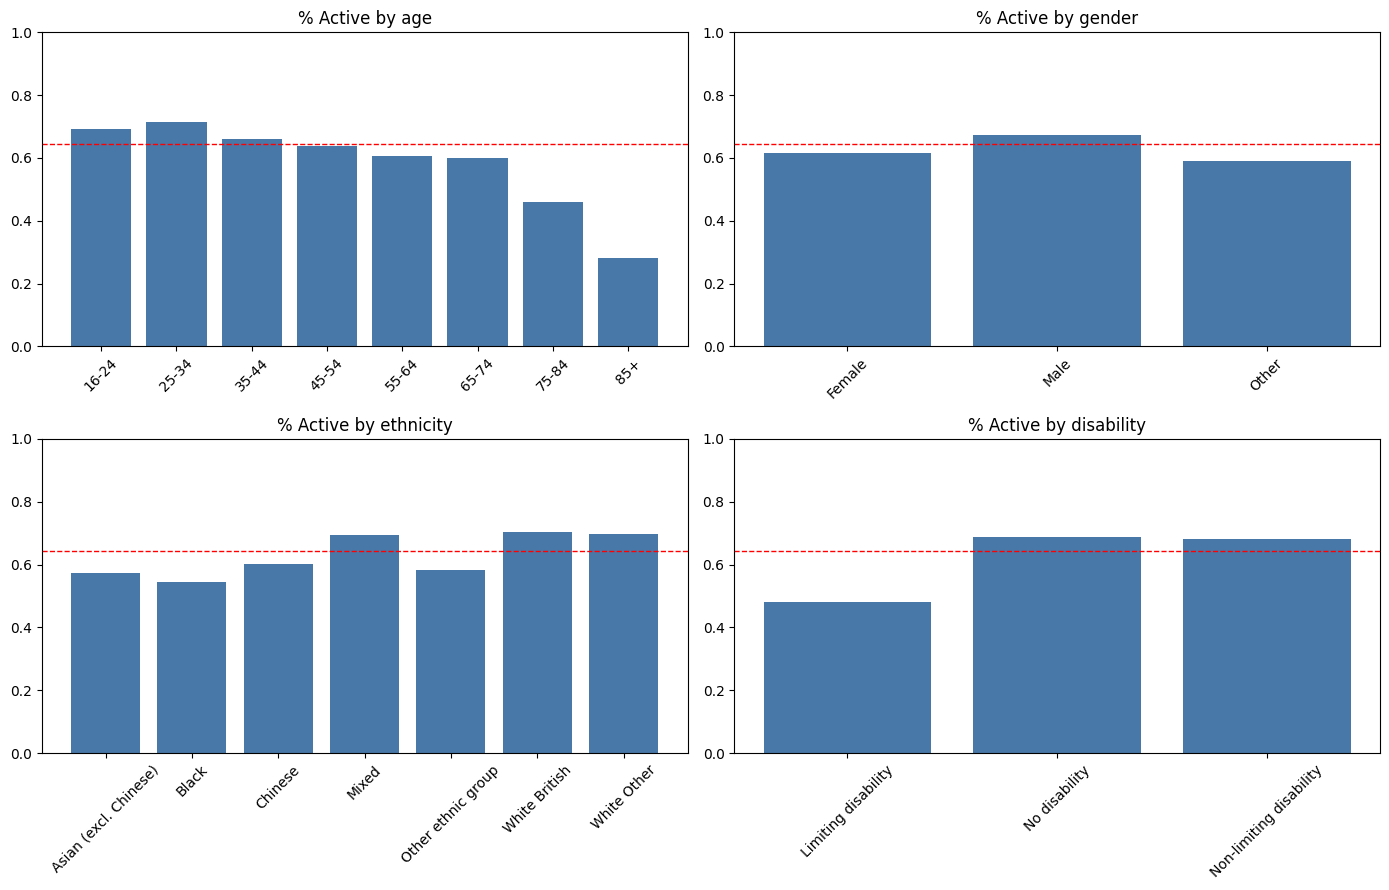

In [11]:
factors = ["age","gender","ethnicity","disability"]
fig, axes = plt.subplots(2,2, figsize=(14,9))
for ax, factor in zip(axes.ravel(), factors):
    res = weighted_share(london, [factor], "activity_band", "Active").dropna(subset=[factor])
    ax.bar(res[factor].astype(str), res["weighted_share"], color="#4878a8")
    ax.axhline(overall, color="red", ls="--", lw=1); ax.set_ylim(0,1)
    ax.set_title(f"% Active by {factor}"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

### Pillar 1 — by borough

               LA_name  weighted_share   n
                Barnet        0.488145 501
                Newham        0.555558 482
              Hounslow        0.557067 488
            Hillingdon        0.564608 490
        Waltham Forest        0.565724 525
               Enfield        0.570528 500
             Redbridge        0.575211 492
                Harrow        0.578040 479
             Greenwich        0.593365 991
                 Brent        0.596025 507
              Havering        0.601354 480
                Bexley        0.611886 493
               Croydon        0.627264 522
               Bromley        0.638713 498
                Merton        0.644233 507
         Tower Hamlets        0.646720 504
               Hackney        0.663115 496
              Haringey        0.665047 532
                Ealing        0.665181 525
  Kingston upon Thames        0.668442 501
             Islington        0.674054 490
           Westminster        0.677421 485
           

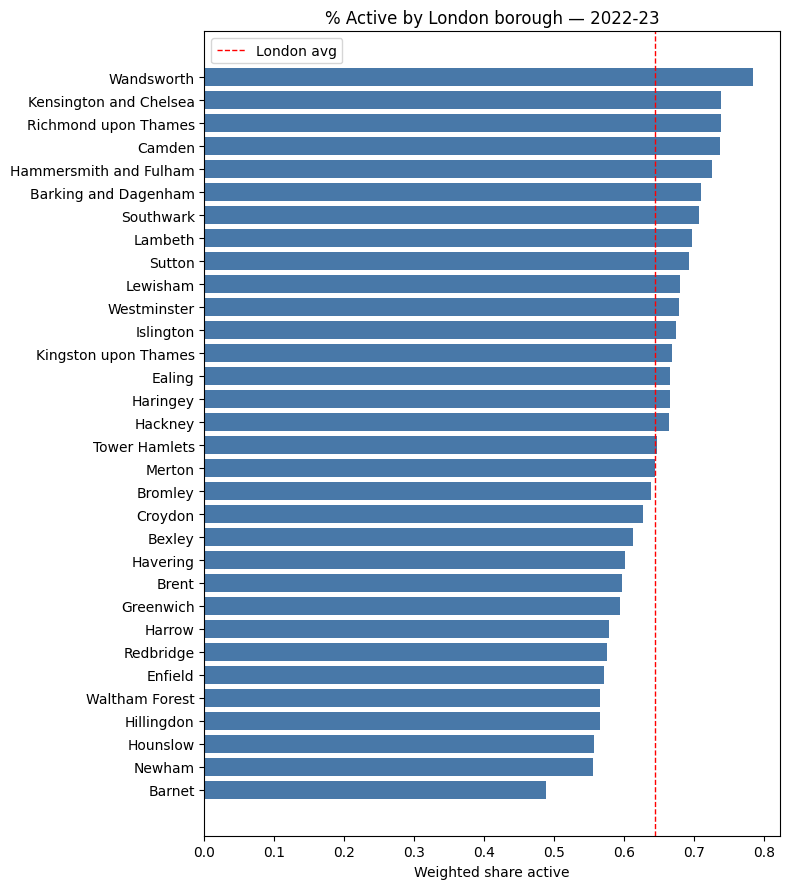

In [12]:
bor = weighted_share(london, ["LA_name"], "activity_band", "Active").sort_values("weighted_share")
print(bor.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,9))
ax.barh(bor["LA_name"], bor["weighted_share"], color="#4878a8")
ax.axvline(overall, color="red", ls="--", lw=1, label="London avg")
ax.set_xlabel("Weighted share active"); ax.set_title("% Active by London borough — 2022-23")
ax.legend(); plt.tight_layout(); plt.show()

## 9. Pillar 2 — Demographics: relationships between variables
Cramér's V measures how strongly two categorical factors move together (0=independent,
1=perfectly associated). Shows which demographics overlap and which independently relate to activity.

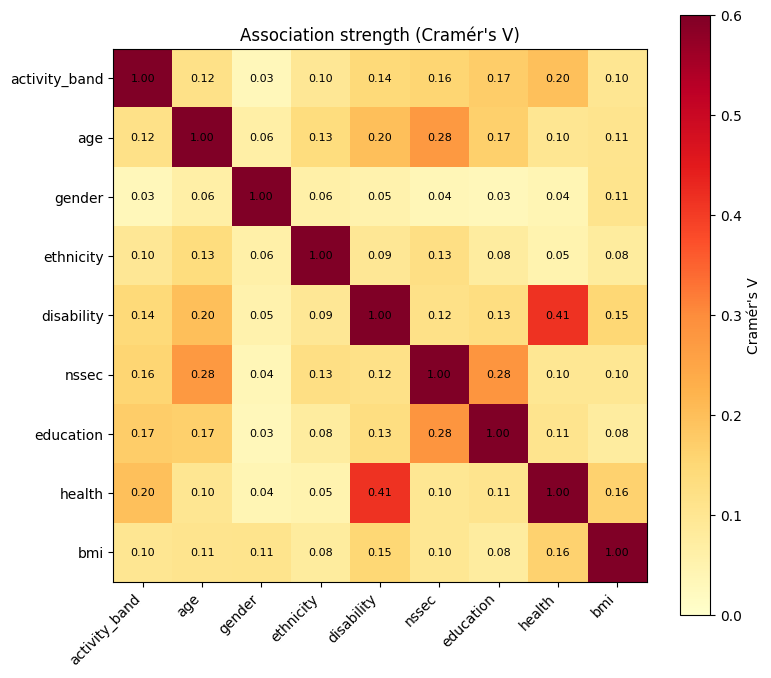

In [13]:
from itertools import combinations
from scipy.stats import chi2_contingency
assoc = ["activity_band","age","gender","ethnicity","disability","nssec","education","health","bmi"]

def cramers_v(a,b,df):
    t = pd.crosstab(df[a], df[b])
    if t.shape[0]<2 or t.shape[1]<2: return np.nan
    chi2 = chi2_contingency(t)[0]; n=t.values.sum(); r,k=t.shape
    return np.sqrt((chi2/n)/(min(r-1,k-1)))

M = pd.DataFrame(np.eye(len(assoc)), index=assoc, columns=assoc)
for a,b in combinations(assoc,2):
    v = cramers_v(a,b,london); M.loc[a,b]=M.loc[b,a]=v

fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(M.values, cmap="YlOrRd", vmin=0, vmax=0.6)
ax.set_xticks(range(len(assoc))); ax.set_xticklabels(assoc, rotation=45, ha="right")
ax.set_yticks(range(len(assoc))); ax.set_yticklabels(assoc)
for i in range(len(assoc)):
    for j in range(len(assoc)):
        ax.text(j,i,f"{M.values[i,j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Association strength (Cramér's V)")
fig.colorbar(im, label="Cramér's V"); plt.tight_layout(); plt.show()

## 10. Pillar 3 — Indoor vs Outdoor
`MEMS7GR_IN/OUT_*` are rotation-subgroup questions (~61% missing) — smaller base, indicative.

Indoor/outdoor base: 6,377 of 16,515
Indoor: weighted % active = 0.257
Outdoor: weighted % active = 0.555

% Active indoor vs outdoor by ethnicity:
place                  Indoor  Outdoor
ethnicity                             
Asian (excl. Chinese)   0.177    0.486
Black                   0.262    0.421
Chinese                 0.303    0.451
Mixed                   0.374    0.613
Other ethnic group      0.248    0.518
White British           0.287    0.637
White Other             0.275    0.584


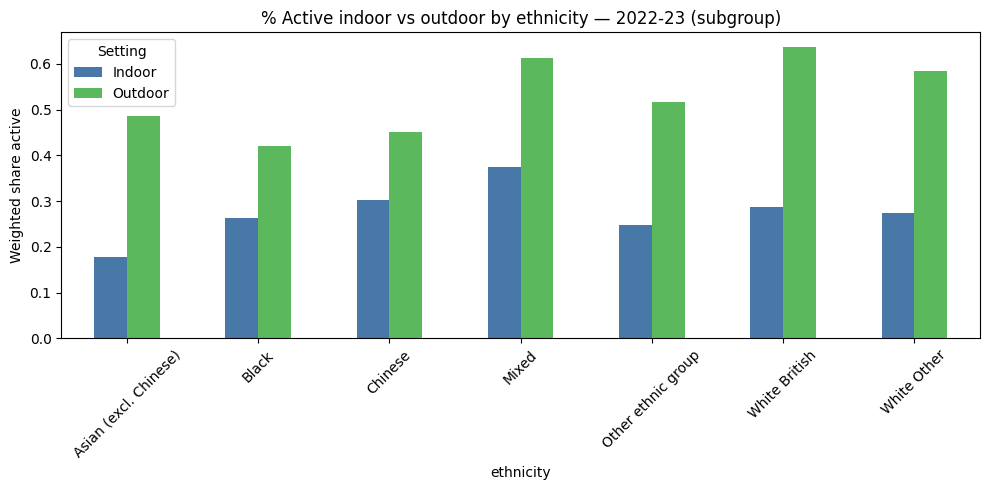

In [14]:
io = london.dropna(subset=["activity_in","activity_out","weight"]).copy()
print(f"Indoor/outdoor base: {len(io):,} of {len(london):,}")
for place,col in [("Indoor","activity_in"),("Outdoor","activity_out")]:
    print(f"{place}: weighted % active = {weighted_share(io, [], col, 'Active'):.3f}")

rows=[]
for col,place in [("activity_in","Indoor"),("activity_out","Outdoor")]:
    r = weighted_share(io, ["ethnicity"], col, "Active").dropna(subset=["ethnicity"]); r["place"]=place; rows.append(r)
pivot = pd.concat(rows).pivot(index="ethnicity", columns="place", values="weighted_share")
print("\n% Active indoor vs outdoor by ethnicity:"); print(pivot.round(3).to_string())
pivot.plot(kind="bar", figsize=(10,5), color=["#4878a8","#5cb85c"])
plt.title("% Active indoor vs outdoor by ethnicity — 2022-23 (subgroup)")
plt.ylabel("Weighted share active"); plt.xticks(rotation=45); plt.legend(title="Setting")
plt.tight_layout(); plt.show()

### Pillar 3 — indoor vs outdoor by borough (subgroup)

In [15]:
rows=[]
for col,place in [("activity_in","Indoor"),("activity_out","Outdoor")]:
    r = weighted_share(io, ["LA_name"], col, "Active").dropna(subset=["LA_name"]); r["place"]=place; rows.append(r)
bor_io = pd.concat(rows).pivot(index="LA_name", columns="place", values="weighted_share")
print(bor_io.round(3).to_string())

place                   Indoor  Outdoor
LA_name                                
Barking and Dagenham     0.293    0.654
Barnet                   0.153    0.370
Bexley                   0.208    0.506
Brent                    0.208    0.480
Bromley                  0.258    0.617
Camden                   0.377    0.606
Croydon                  0.248    0.478
Ealing                   0.241    0.511
Enfield                  0.221    0.549
Greenwich                0.290    0.534
Hackney                  0.304    0.626
Hammersmith and Fulham   0.339    0.680
Haringey                 0.246    0.631
Harrow                   0.167    0.506
Havering                 0.248    0.505
Hillingdon               0.230    0.458
Hounslow                 0.093    0.514
Islington                0.261    0.645
Kensington and Chelsea   0.345    0.607
Kingston upon Thames     0.254    0.614
Lambeth                  0.375    0.612
Lewisham                 0.262    0.606
Merton                   0.280    0.568


## 11. Pillar 4 — Volunteering
`VolAny` = headline (did they volunteer). Role types are 0/1 flags among volunteers only.

In [16]:
volr = weighted_share(london, [], "volunteer", "Volunteered")
print(f"Overall weighted % volunteered: {volr:.3f}")
for factor in ["age","gender","disability","nssec"]:
    print(f"\n=== % Volunteered by {factor} ===")
    print(weighted_share(london, [factor], "volunteer", "Volunteered").dropna(subset=[factor]).to_string(index=False))

Overall weighted % volunteered: 0.183

=== % Volunteered by age ===
  age  weighted_share    n
16-24        0.259895 1266
25-34        0.165414 2491
35-44        0.174543 2925
45-54        0.191054 2295
55-64        0.156902 1886
65-74        0.162115 1261
75-84        0.137006  545
  85+        0.092638   92

=== % Volunteered by gender ===
gender  weighted_share    n
Female        0.153618 7090
  Male        0.210984 5620
 Other        0.198274  116

=== % Volunteered by disability ===
             disability  weighted_share    n
    Limiting disability        0.164404 1719
          No disability        0.190922 8537
Non-limiting disability        0.172156 1586

=== % Volunteered by nssec ===
                            nssec  weighted_share    n
Higher social groups (NS-SEC 1-2)        0.191699 7854
 Lower social groups (NS-SEC 6-8)        0.112553 1086
Middle social groups (NS-SEC 3-5)        0.196101 2036
  Students and other/unclassified        0.215122 1215


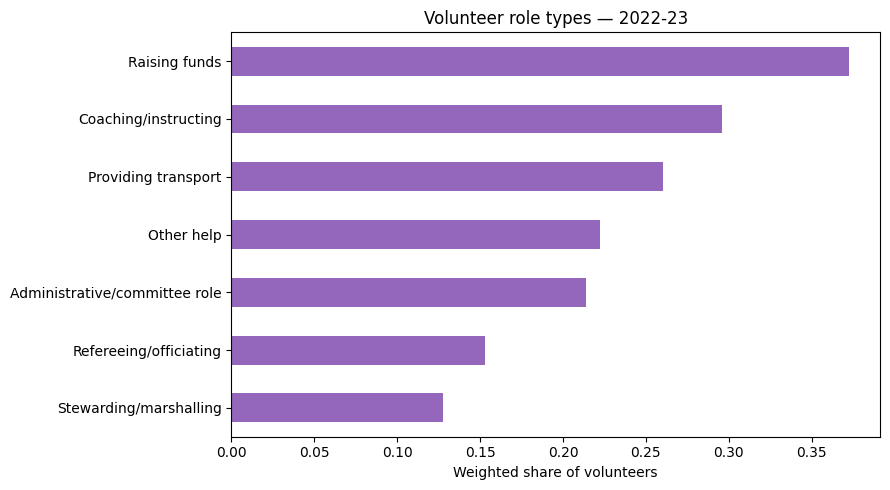

Stewarding/marshalling           0.127
Refereeing/officiating           0.153
Administrative/committee role    0.214
Other help                       0.222
Providing transport              0.260
Coaching/instructing             0.296
Raising funds                    0.373


In [17]:
vols = london[london["volunteer"]=="Volunteered"].dropna(subset=["weight"]).copy()
role_share={}
for col,label in VOL_ROLES.items():
    if col in vols.columns:
        d = vols.dropna(subset=[col]); role_share[label]=(d[col]*d["weight"]).sum()/d["weight"].sum()
rs = pd.Series(role_share).sort_values()
fig, ax = plt.subplots(figsize=(9,5))
rs.plot(kind="barh", ax=ax, color="#9467bd")
ax.set_xlabel("Weighted share of volunteers"); ax.set_title("Volunteer role types — 2022-23")
plt.tight_layout(); plt.show()
print(rs.round(3).to_string())

### Pillar 4 — volunteering rate by borough

In [18]:
vbor = weighted_share(london, ["LA_name"], "volunteer", "Volunteered").sort_values("weighted_share")
print(vbor.to_string(index=False))

               LA_name  weighted_share   n
           Westminster        0.118122 364
               Hackney        0.145739 375
              Lewisham        0.152261 405
              Havering        0.152543 357
                Newham        0.156403 404
                Barnet        0.156625 388
                 Brent        0.158644 393
             Islington        0.159324 364
        Waltham Forest        0.159690 417
         Tower Hamlets        0.164602 426
             Southwark        0.167803 415
Hammersmith and Fulham        0.170492 372
             Greenwich        0.172382 773
Kensington and Chelsea        0.173655 407
                Sutton        0.175312 339
                Camden        0.175349 404
                Bexley        0.177427 385
               Lambeth        0.178522 398
  Barking and Dagenham        0.179399 370
            Hillingdon        0.182811 384
              Haringey        0.186875 416
  Kingston upon Thames        0.187578 385
           

## 12. Weighted regression — drivers of being active (adjusted)
Mirrors 2015-16, adding NS-SEC and health. Odds of being active, holding other factors constant.
**Caveat (important):** `freq_weights` treats survey weights as frequency counts, which inflates the
effective N (note the non-integer, >N residual df) and makes **all p-values and confidence intervals
unreliable — not merely optimistic**. Quote the odds ratios as descriptive effect sizes; do NOT cite
the significance stats. Design-based inference (a survey package) is needed for valid p-values.
The model also uses complete cases only (~80% of the sample); see the printed drop.

In [19]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
m = london.dropna(subset=["activity_band","age","gender","disability",
                          "ethnicity","nssec","health","weight"]).copy()
m["active"] = (m["activity_band"]=="Active").astype(int)
print(f"Regression complete-case sample: {len(m):,} of {len(london):,} "
      f"({len(m)/len(london):.0%}) — {len(london)-len(m):,} rows dropped for missing predictors "
      f"(mostly NS-SEC and health). Complete-case deletion may bias estimates if missingness is non-random.")
model = smf.glm(
    'active ~ C(age) '
    '+ C(gender, Treatment(reference="Female")) '
    '+ C(disability, Treatment(reference="No disability")) '
    '+ C(ethnicity, Treatment(reference="White British")) '
    '+ C(nssec) + C(health)',
    data=m, family=sm.families.Binomial(), freq_weights=m["weight"]).fit()
print(model.summary())

Regression complete-case sample: 13,238 of 16,515 (80%) — 3,277 rows dropped for missing predictors (mostly NS-SEC and health). Complete-case deletion may bias estimates if missingness is non-random.
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 active   No. Observations:                13238
Model:                            GLM   Df Residuals:                 21651.52
Model Family:                Binomial   Df Model:                           22
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -12522.
Date:                Sun, 28 Jun 2026   Deviance:                       25044.
Time:                        16:24:37   Pearson chi2:                 2.15e+04
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1539
Covariance Type:            nonrobust                                         
          

In [20]:
or_table = pd.DataFrame({
    "odds_ratio": np.exp(model.params), "p_value": model.pvalues,
    "ci_low": np.exp(model.conf_int()[0]), "ci_high": np.exp(model.conf_int()[1]),
}).round(3)
print(or_table.to_string())

                                                                                odds_ratio  p_value  ci_low  ci_high
Intercept                                                                            1.957    0.000   1.604    2.389
C(age)[T.25-34]                                                                      0.755    0.000   0.668    0.853
C(age)[T.35-44]                                                                      0.678    0.000   0.599    0.768
C(age)[T.45-54]                                                                      0.609    0.000   0.536    0.692
C(age)[T.55-64]                                                                      0.519    0.000   0.455    0.593
C(age)[T.65-74]                                                                      0.432    0.000   0.374    0.499
C(gender, Treatment(reference="Female"))[T.Male]                                     1.177    0.000   1.107    1.250
C(gender, Treatment(reference="Female"))[T.Other]               

## 13. Save cleaned data & wave comparison

In [21]:
london.to_parquet("london_2022_23_clean.parquet")
print("saved london_2022_23_clean.parquet", london.shape)
compare = pd.DataFrame({"wave":["2015-16","2022-23"],
    "overall_pct_active":[0.635, round(weighted_share(london, [], "activity_band", "Active"),3)]})
print(compare.to_string(index=False))

saved london_2022_23_clean.parquet (16515, 616)
   wave  overall_pct_active
2015-16               0.635
2022-23               0.643


## Findings — to complete after running

- **Overall active rate 2022-23:** ___ % (vs 63.5% in 2015-16).
- **Borough range:** highest ___ , lowest ___ (mind sample sizes via `n`).
- **Indoor vs outdoor:** outdoor base shows ___; by-ethnicity pattern ___.
- **Volunteering:** ___ % volunteered; most common role = ___; borough variation ___.
- **Regression:** significant adjusted drivers were ___; ___ became non-significant.

### Caveats
- Indoor/outdoor and some volunteering items are **rotation-subgroup** (~61% missing by design).
- Borough × demographic cells get small — always read `n`.
- ⚠️ Verify codebook bands for Age9 / NSSEC5 / BMIG / health against the data dictionary.
- City of London excluded per project scope (32 boroughs).

### Next steps
- Harmonise activity/ethnicity/age categories with 2015-16 for the panel; then trend & forecasting.

In [23]:
from codebook_gen import build_codebook, compare_codebooks
import json

SAV_2022 = r"C:/Users/Lenovo/London-Sport-Forecasting-Patterns/data/raw/active_lives_survey_nov_22-23_data_year_8_shared_20250103.sav"

CONCEPT_VARS = ["MEMS7GR_SPORTCOUNT_A01","MEMS7GR_ALL",
                "MEMS7GR_IN_SPORTCOUNT_A01","MEMS7GR_OUT_SPORTCOUNT_A01",
                "Gend3","Eth7","Eth2","Disab3","Disab2_POP",
                "Age9","Age5_2","NSSEC5","Educ6","health","BMIG",
                "VolAny","VolCnt_GR2","VolFrqB_Pop"]
ROLE_VARS = [f"volint{i}_vol" for i in range(1, 8)]

# Build the baseline codebook from the 2022-23 .sav
CODEBOOK, ROLE_LABELS, MISSING_CODES = build_codebook(SAV_2022, CONCEPT_VARS, ROLE_VARS)

# SAVE it as the reference all other waves get checked against (run this ONCE)
json.dump({k:{str(c):l for c,l in m.items()} for k,m in CODEBOOK.items()},
          open("baseline_codebook.json","w"), indent=2)
print("baseline_codebook.json saved")

baseline_codebook.json saved


In [26]:
import pandas as pd
df16 = pd.read_csv(r"C:\Users\Lenovo\London-Sport-Forecasting-Patterns\data\processed\active_lives_london_y2_2016-17.csv")
print("shape:", df16.shape)
print("survey year:", df16["survey_year"].unique() if "survey_year" in df16 else "no survey_year col")

# Does it have the baseline columns the notebook expects?
need = ["wt_final","LA_2021","MEMS7GR_SPORTCOUNT_A01","Eth7","Disab3","Age9","VolAny"]
print("missing baseline columns:", [c for c in need if c not in df16.columns])

shape: (19248, 498)
survey year: ['2016-17']
missing baseline columns: []


In [27]:
validate_wave(df16, "2016-17", expected_active=0.62)

=== validate_wave: 2016-17 -> PASS ===


[]

In [28]:
present = sorted(int(x) for x in df16["LA_2021"].dropna().unique())
mapped = sorted(LONDON_LA2021.keys())
print("distinct LA_2021 codes in 2016-17:", present)
print("in data but NOT in baseline map:", sorted(set(present) - set(LONDON_LA2021)))
print("in baseline map but NOT in data:", sorted(set(LONDON_LA2021) - set(present)))
print("borough coverage:", df16["LA_2021"].map({k:v[0] for k,v in LONDON_LA2021.items()}).notna().mean())

distinct LA_2021 codes in 2016-17: [8, 9, 17, 30, 35, 44, 69, 80, 94, 110, 112, 115, 117, 120, 125, 129, 132, 138, 139, 143, 146, 151, 164, 175, 201, 206, 247, 261, 278, 285, 286, 300]
in data but NOT in baseline map: []
in baseline map but NOT in data: [59]
borough coverage: 1.0


In [29]:
from codebook_gen import build_codebook, compare_codebooks
import json
baseline = {k:{int(c):l for c,l in m.items()} for k,m in json.load(open("baseline_codebook.json")).items()}
new_cb, _, _ = build_codebook(r"C:/Users/Lenovo/London-Sport-Forecasting-Patterns/data/raw/active_lives_survey_nov_16-17_data_year_2_shared_20250106.sav", CONCEPT_VARS, ROLE_VARS)
compare_codebooks(baseline, new_cb, "2016-17")

=== codebook comparison: baseline vs 2016-17 -> 12 DIFFERENCE(S) ===
  - MEMS7GR_SPORTCOUNT_A01[1]: baseline='Fairly Active' vs 2016-17='Insufficiently Active'
  - MEMS7GR_ALL[1]: baseline='Fairly Active' vs 2016-17='Insufficiently Active'
  - Eth7[3]: baseline='Asian (excl. Chinese)' vs 2016-17='South Asian'
  - Eth2[1]: baseline='White British' vs 2016-17='White-British'
  - Eth2[2]: baseline='Non White British' vs 2016-17='Non white-British'
  - Age5_2: codes in 2016-17 but not baseline: [0]
  - NSSEC5: codes in 2016-17 but not baseline: [5]
  - NSSEC5[4]: baseline='NS SEC 9: Students and other / unclassified' vs 2016-17='NS SEC 9: Students and other'
  - health: MISSING from 2016-17
  - VolAny: MISSING from 2016-17
  - VolCnt_GR2: MISSING from 2016-17
  - VolFrqB_Pop: MISSING from 2016-17


["MEMS7GR_SPORTCOUNT_A01[1]: baseline='Fairly Active' vs 2016-17='Insufficiently Active'",
 "MEMS7GR_ALL[1]: baseline='Fairly Active' vs 2016-17='Insufficiently Active'",
 "Eth7[3]: baseline='Asian (excl. Chinese)' vs 2016-17='South Asian'",
 "Eth2[1]: baseline='White British' vs 2016-17='White-British'",
 "Eth2[2]: baseline='Non White British' vs 2016-17='Non white-British'",
 'Age5_2: codes in 2016-17 but not baseline: [0]',
 'NSSEC5: codes in 2016-17 but not baseline: [5]',
 "NSSEC5[4]: baseline='NS SEC 9: Students and other / unclassified' vs 2016-17='NS SEC 9: Students and other'",
 'health: MISSING from 2016-17',
 'VolAny: MISSING from 2016-17',
 'VolCnt_GR2: MISSING from 2016-17',
 'VolFrqB_Pop: MISSING from 2016-17']

In [30]:
print(df16["VolAny"].notna().sum(), "non-null VolAny in the 2016-17 CSV")
print(df16["VolAny"].value_counts(dropna=False))
print("health in CSV?", "health" in df16.columns, "| non-null:", df16["health"].notna().sum() if "health" in df16 else "n/a")

12466 non-null VolAny in the 2016-17 CSV
VolAny
0.0    9726
NaN    6782
1.0    2740
Name: count, dtype: int64
health in CSV? False | non-null: n/a


In [31]:
# What are the extra NSSEC5 and Age5_2 codes, and do indoor/outdoor exist?
print("NSSEC5 values:", sorted(df16["NSSEC5"].dropna().unique()))
print("Age5_2 values:", sorted(df16["Age5_2"].dropna().unique()))
print("indoor/outdoor present?",
      [c for c in ["MEMS7GR_IN_SPORTCOUNT_A01","MEMS7GR_OUT_SPORTCOUNT_A01"] if c in df16.columns])

NSSEC5 values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
Age5_2 values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
indoor/outdoor present? ['MEMS7GR_IN_SPORTCOUNT_A01', 'MEMS7GR_OUT_SPORTCOUNT_A01']


In [33]:
import pyreadstat
_, meta16 = pyreadstat.read_sav(
    r"C:/Users/Lenovo/London-Sport-Forecasting-Patterns/data/raw/active_lives_survey_nov_16-17_data_year_2_shared_20250106.sav",
    metadataonly=True
)
print(meta16.variable_value_labels.get("NSSEC5"))

{-99.0: 'Missing, should have been answered', -98.0: 'Not applicable: Survey routing', -97.0: 'Incorrectly multicoded', -96.0: 'Out of range', -95.0: "Cannot give an estimate / Don't know", -94.0: 'Prefer not to say', -93.0: 'Not applicable: Postal response', -92.0: 'Not applicable: Phase 1 case', -91.0: 'Not applicable: Phase 2 case', -90.0: 'Not applicable: Not asked to this group', 1.0: 'NS SEC 1-2: Higher social groups', 2.0: 'NS SEC 3-5: Middle social groups', 3.0: 'NS SEC 6-8: Lower social groups', 4.0: 'NS SEC 9: Students and other', 5.0: 'Aged <16 or 75+'}
